# FITS Imaging — Version 2.2 cleaned driver notebook

This notebook keeps interactive work in Jupyter while moving reusable code into the `fits_imaging` package. The package functions are written so they can later be used by a command-line program or GUI.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from fits_imaging.config import ImagingConfig
from fits_imaging.fits_io import choose_file
from fits_imaging.analysis import analyze_fits_file
from fits_imaging.report import print_image_summary, print_peak_table
from fits_imaging.plotting import (
    plot_image_with_peaks,
    plot_peak_cutouts,
    plot_histogram,
)

config = ImagingConfig()
config


ImagingConfig(data_root=PosixPath('/Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories'), zero_mag_counts=115000000, pixel_arcsec=1.24, threshold_sigma=5.0, max_peaks=1000, peak_separation=10.0, contrast_method='sigma', contrast_percentiles=(1.0, 99.8), contrast_sigma_low=1.0, contrast_sigma_high=5.0, stretch='linear', colormap='viridis', invert_colormap=False, invert_gray=False, histogram_max_points=2000000, histogram_bins=200)

## Select a FITS file

Set `data_root` to your top-level `DataDirectories` folder. `choose_file()` now handles either case: a folder containing FITS files directly, or a folder containing subdirectories of FITS files.


In [3]:
config = ImagingConfig()
image_path = choose_file(config.data_root, extensions=(".fits", ".fit"))
image_path


Directory#   Directory
----------------------------------------------------------------------
    0       Archive
    1       CowTests
    2       Images
    3       Lib-0610
    4       Patio-0703
----------------------------------------------------------------------


Choose directory number:  4



File#       File
----------------------------------------------------------------------
    0       VegaC0-Baht_2026-07-04_04.02.22_CuED-0.fits
    1       VegaC0-Baht_2026-07-04_04.18.17_CuED-0.fits
    2       VegaC0_2026-07-04_03.48.12_CuED-0.fits
    3       VegaC0_2026-07-04_03.57.22_CuED-0.fits
    4       VegaC0_2026-07-04_04.20.58_CuED-0.fits
    5       VegaC0_2026-07-04_04.30.06_CuED-0.fits
    6       VegaD1-Baht_2026-07-04_04.04.48_CuED-0.fits
    7       VegaD1_2026-07-04_03.50.39_CuED-0.fits
    8       VegaD1_2026-07-04_04.23.23_CuED-0.fits
    9       VegaD2-Baht_2026-07-04_04.05.24_CuED-0.fits
   10       VegaD2_2026-07-04_03.51.15_CuED-0.fits
   11       VegaD2_2026-07-04_04.23.59_CuED-0.fits
   12       VegaD3-Baht_2026-07-04_04.06.00_CuED-0.fits
   13       VegaD3_2026-07-04_03.51.52_CuED-0.fits
   14       VegaD3_2026-07-04_04.24.35_CuED-0.fits
   15       VegaL1-Baht_2026-07-04_04.09.05_CuED-0.fits
   16       VegaL1_2026-07-04_03.54.56_CuED-0.fits
   17       Ve

Enter file number to analyze:  4


PosixPath('/Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories/Patio-0703/VegaC0_2026-07-04_04.20.58_CuED-0.fits')

## Read image and find peaks

In [5]:
record, imagec, peaksarray, stats = analyze_fits_file(
    image_path,
    peak_separation=10.0,
    peak_sharp=0.2,
    maxsources=400,
    fit_method='gaussian',   # use 'moments' for faster center-of-light estimates
)

print_image_summary(record, imagec, stats)

VegaC0  9576 x 6380  Apx60-CuED  0.001 sec
RAH:  18.630  Dec:  38.810  PA: 286.40  PA2:  73.60  Alt:    47.9  Az:    71.1
Mean: 99.1  Median: 99.0  Std: 4.6  Min: 0.0  Max: 3044.0
Found 5 peaks in 2.68 sec


## Full image with labeled peaks

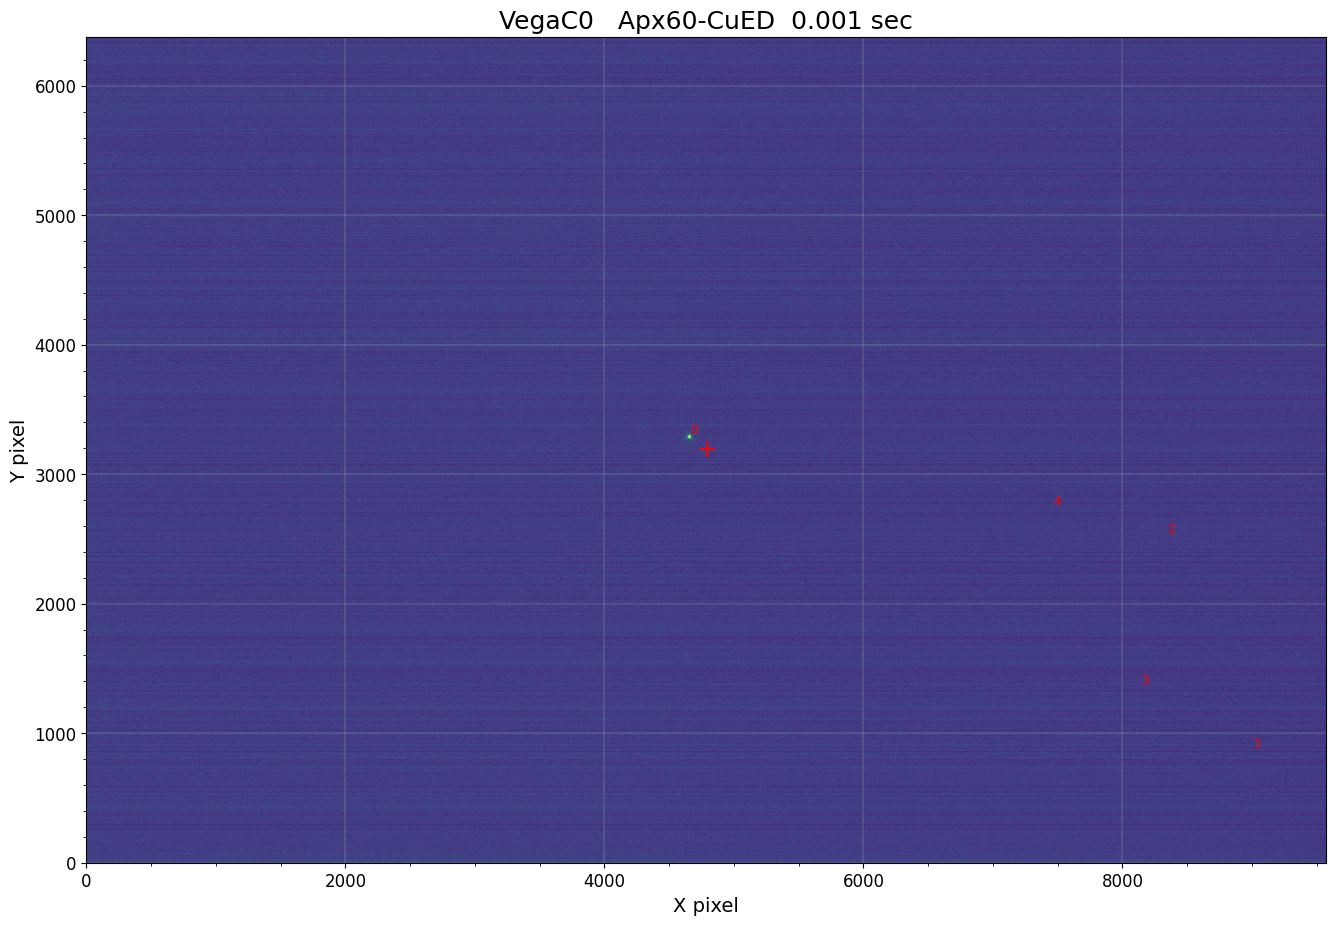

In [7]:
title = f'{record.object_name}   {record.camera}  {record.exposure_sec:.3f} sec'
fig, ax = plot_image_with_peaks(
    imagec,
    peaksarray,
    title=title,
    figsize=(16, 16),
    config=config,
)
plt.show()

## Peak table

In [9]:
swarpfac = -1.0 if record.softname == 'SWarp' else 1.0
print_peak_table(
    peaksarray,
    exposure_sec=record.exposure_sec,
    zero_mag_counts=config.zero_mag_counts,
    pa0=record.pa_deg,
    swarpfac=swarpfac,
    max_rows=200,
)


Peak#        X        Y        Area       sx      sy        Flux      Mag
------------------------------------------------------------------------------
    0   4659.55   3289.57     30781.6    1.18    1.64     37555.0    1.215
    1   9012.30    877.52       152.7    0.53    0.60       154.0    7.183
    2   8348.12   2527.91       186.9    0.37    0.98       148.0    7.226
    3   8142.66   1361.49       180.7    0.75    0.60       140.0    7.286
    4   7470.33   2743.41       146.9    0.47    0.52       126.0    7.401


## Peak cutouts

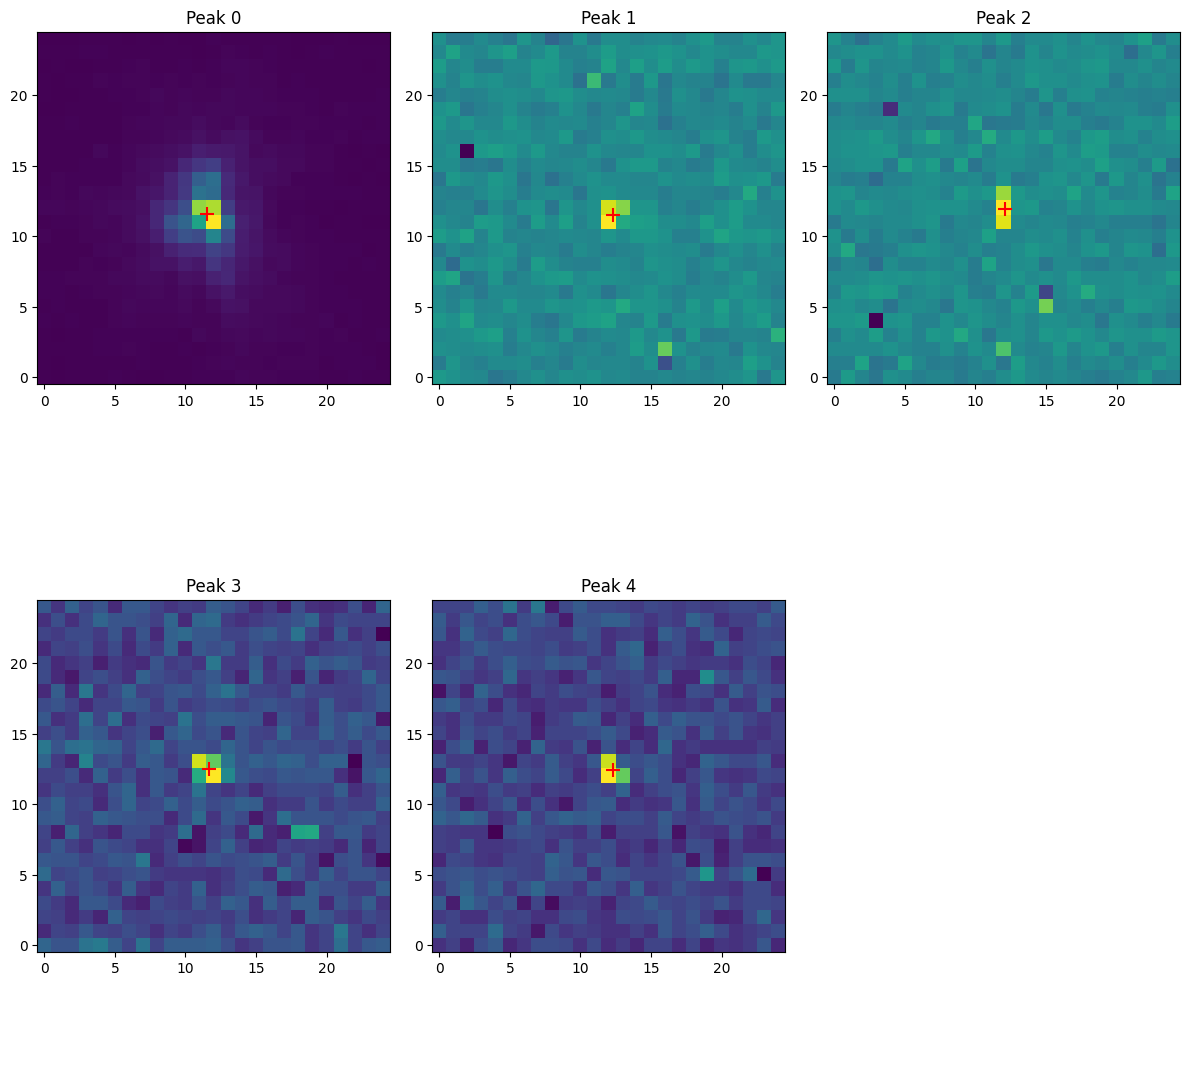

In [11]:
if len(peaksarray) > 0:
    fig, axs = plot_peak_cutouts(
        imagec,
        peaksarray,
        nmax=25,
        spansize=24,
        pixel_arcsec=config.pixel_arcsec,
        exposure_sec=record.exposure_sec,
        zero_mag_counts=config.zero_mag_counts,
    )
    plt.show()
else:
    print('No peaks found.')

## Optional diagnostic plots

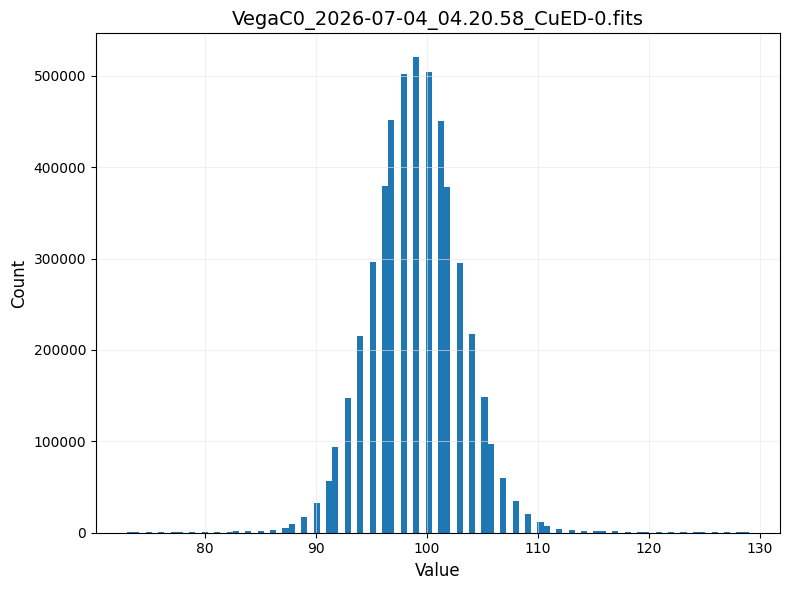

In [13]:
fig, ax = plot_histogram(imagec, title=record.filename)
plt.show()

In [ ]:
convolved_image, fig, ax = plot_convolved_image(imagec, title=f'{record.filename}: W5x5 convolution')
plt.show()